**Predict-before-run, Q1:** OverkillModel in Day 37 had a train/test gap of 0.4933. If you add dropout with 50% rate (half the neurons zeroed each step), do you expect the training loss to go up, down, or stay the same compared to without dropout? What about the test loss? Think about both directions before running Part 1.

*i think the training loss could be the same or even get down , but the test loss definately goes down and the gap lessens*

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

X_train, X_test = X[:80], X[80:]
y_train, y_test = y[:80], y[80:]
loss_fn = nn.BCEWithLogitsLoss()

# WITHOUT dropout (same OverkillModel as Day 37)
class OverkillModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
    def forward(self, x):
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = torch.relu(self.h3(x))
        x = torch.relu(self.h4(x))
        return self.output(x)

# WITH dropout
class OverkillWithDropout(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        self.dropout = nn.Dropout(p=p)   # TODO: what does p=0.5 mean specifically?
                                                                  #i think it means that  50 percent of the neurons will get turned off

    def forward(self, x):
        x = torch.relu(self.dropout(self.h1(x)))   # dropout applied after each hidden layer
        x = torch.relu(self.dropout(self.h2(x)))   # TODO: why not apply dropout after output layer?
        x = torch.relu(self.dropout(self.h3(x)))    # if we applied the dropout layer after output that means
        x = torch.relu(self.dropout(self.h4(x)))    #it will switch off the random neurons after the final prediction
        return self.output(x)                              #is made that can mess with the  final answers

def train_and_evaluate(model, epochs=2000, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        y_pred_train = model(X_train)
        loss_train = loss_fn(y_pred_train, y_train)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        train_losses.append(loss_train.item())

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)   # this line was missing in Day 37 — now it's here # got it
            loss_test = loss_fn(y_pred_test, y_test)
        test_losses.append(loss_test.item())
    return train_losses, test_losses

no_drop_train, no_drop_test = train_and_evaluate(OverkillModel())
drop_train, drop_test = train_and_evaluate(OverkillWithDropout(p=0.5))

print("=== Without dropout ===")
print(f"Train: {no_drop_train[-1]:.4f} | Test: {no_drop_test[-1]:.4f} | Gap: {no_drop_test[-1]-no_drop_train[-1]:.4f}")

print("\n=== With dropout (p=0.5) ===")
print(f"Train: {drop_train[-1]:.4f} | Test: {drop_test[-1]:.4f} | Gap: {drop_test[-1]-drop_train[-1]:.4f}")

=== Without dropout ===
Train: 0.3394 | Test: 1.1553 | Gap: 0.8159

=== With dropout (p=0.5) ===
Train: 0.6512 | Test: 0.7446 | Gap: 0.0935


**Checkpoint:** With dropout, training loss should be *higher* than without (harder to memorize), but test loss should be *lower* (better generalization). The gap should shrink. If dropout made both losses worse, try `p=0.3` — 50% may be too aggressive for this small model.


=== Without dropout ===
Train: 0.3436 | Test: 1.1549 | Gap: 0.8113

=== With dropout (p=0.5) ===
Train: 0.6479 | Test: 0.7440 | Gap: 0.0962

*iwas correct about the test loss and the gap , just got to know now that the train loss went up instead of going down*




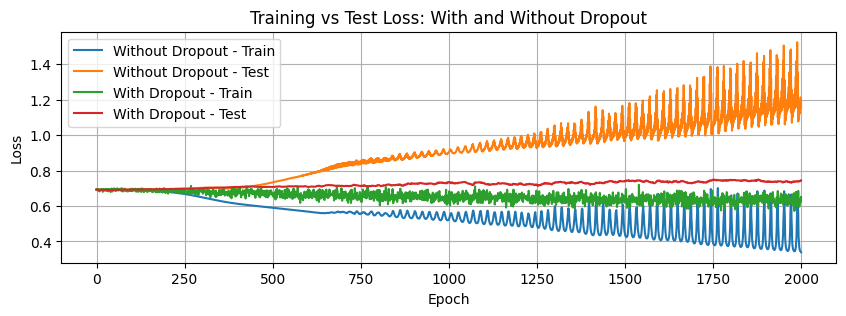

In [2]:
plt.figure(figsize=(10, 3))

plt.plot(no_drop_train, label="Without Dropout - Train")
plt.plot(no_drop_test, label="Without Dropout - Test")

plt.plot(drop_train, label="With Dropout - Train")
plt.plot(drop_test, label="With Dropout - Test")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss: With and Without Dropout")
plt.legend()
plt.grid(True)

plt.show()

# without dropout the train and test loss really goes up and down ,like really oscillating and extremes
#up and down , while the test loss with dropout was straight , and the same in way goes for train loss with dropout
#really less oscillations


In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

X_train, X_test = X[:80], X[80:]
y_train, y_test = y[:80], y[80:]
loss_fn = nn.BCEWithLogitsLoss()

# WITHOUT dropout (same OverkillModel as Day 37)
class OverkillModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
    def forward(self, x):
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = torch.relu(self.h3(x))
        x = torch.relu(self.h4(x))
        return self.output(x)

# WITH dropout
class OverkillWithDropout(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        self.dropout = nn.Dropout(p=p)   # TODO: what does p=0.5 mean specifically?
                                                                  #i think it means that  50 percent of the neurons will get turned off

    def forward(self, x):
        x = torch.relu(self.dropout(self.h1(x)))   # dropout applied after each hidden layer
        x = torch.relu(self.dropout(self.h2(x)))   # TODO: why not apply dropout after output layer?
        x = torch.relu(self.dropout(self.h3(x)))    # if we applied the dropout layer after output that means
        x = torch.relu(self.dropout(self.h4(x)))    #it will switch off the random neurons after the final prediction
        return self.output(x)                              #is made that can mess with the  final answers

def train_and_evaluate(model, epochs=2000, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        y_pred_train = model(X_train)
        loss_train = loss_fn(y_pred_train, y_train)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        train_losses.append(loss_train.item())

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)   # this line was missing in Day 37 — now it's here # got it
            loss_test = loss_fn(y_pred_test, y_test)
        test_losses.append(loss_test.item())
    return train_losses, test_losses

no_drop_train, no_drop_test = train_and_evaluate(OverkillModel())
drop_train, drop_test = train_and_evaluate(OverkillWithDropout(p=0.5))

print("=== Without dropout ===")
print(f"Train: {no_drop_train[-1]:.4f} | Test: {no_drop_test[-1]:.4f} | Gap: {no_drop_test[-1]-no_drop_train[-1]:.4f}")

print("\n=== With dropout (p=0.5) ===")
print(f"Train: {drop_train[-1]:.4f} | Test: {drop_test[-1]:.4f} | Gap: {drop_test[-1]-drop_train[-1]:.4f}")


# === Without dropout ===
# Train: 0.3436 | Test: 1.1549 | Gap: 0.8113

# === With dropout (p=0.5) ===
# Train: 0.6479 | Test: 0.7440 | Gap: 0.0962

#even with 0.3 , its the same answer

=== Without dropout ===
Train: 0.3394 | Test: 1.1553 | Gap: 0.8159

=== With dropout (p=0.5) ===
Train: 0.6512 | Test: 0.7446 | Gap: 0.0935


In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

X_train, X_test = X[:80], X[80:]
y_train, y_test = y[:80], y[80:]
loss_fn = nn.BCEWithLogitsLoss()

class OverkillModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
    def forward(self, x):
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = torch.relu(self.h3(x))
        x = torch.relu(self.h4(x))
        return self.output(x)



def train_with_wd(weight_decay_val, epochs=2000):
    model = OverkillModel()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay_val)
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            loss_test = loss_fn(y_pred_test, y_test)
        test_losses.append(loss_test.item())
    return train_losses, test_losses

wd_0_train, wd_0_test = train_with_wd(0)          # no weight decay
wd_train, wd_test = train_with_wd(1e-3)            # weight decay = 0.001

print("=== No weight decay ===")
print(f"Train: {wd_0_train[-1]:.4f} | Test: {wd_0_test[-1]:.4f} | Gap: {wd_0_test[-1]-wd_0_train[-1]:.4f}")

print("\n=== Weight decay 1e-3 ===")
print(f"Train: {wd_train[-1]:.4f} | Test: {wd_test[-1]:.4f} | Gap: {wd_test[-1]-wd_train[-1]:.4f}")

=== No weight decay ===
Train: 0.3394 | Test: 1.1553 | Gap: 0.8159

=== Weight decay 1e-3 ===
Train: 0.3667 | Test: 0.9946 | Gap: 0.6278


=== No weight decay ===
Train: 0.3436 | Test: 1.1549 | Gap: 0.8113

=== Weight decay 1e-3 ===
Train: 0.5111 | Test: 1.1270 | Gap: 0.6160


*some days before i did this answer was this ,  for thr weight decay model*

now its this as of today

=== No weight decay ===
Train: 0.3394 | Test: 1.1553 | Gap: 0.8159

=== Weight decay 1e-3 ===
Train: 0.3667 | Test: 0.9946 | Gap: 0.6278


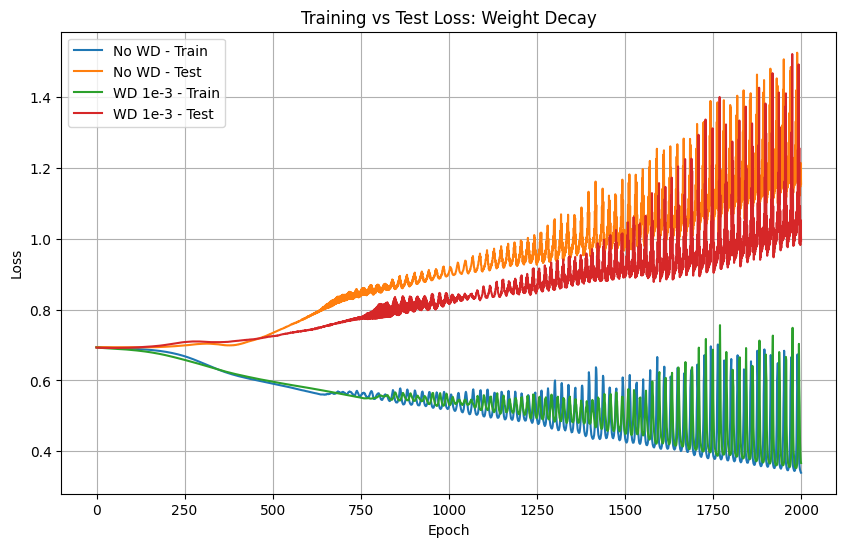

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(wd_0_train, label="No WD - Train")
plt.plot(wd_0_test, label="No WD - Test")

plt.plot(wd_train, label="WD 1e-3 - Train")
plt.plot(wd_test, label="WD 1e-3 - Test")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss: Weight Decay")
plt.legend()
plt.grid(True)

plt.show()

# TODO: weight_decay=1e-3 means 0.001 — what does this number actually do to the loss?
# Hint: the optimizer adds weight_decay * sum(w^2) to the loss before computing gradients


*the weight decay
   Total Loss=Prediction Loss+λ∑w2​
weights are continually nudged toward smaller values so the model doesnt take large and complex weights and move towards smaller ones  to prevent overfiting*



In [6]:
# Train two fresh OverkillModels — one with each optimizer:

# ```python
def train_with_wd(weight_decay_val, epochs=2000):
    model = OverkillModel()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay_val)
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            loss_test = loss_fn(y_pred_test, y_test)
        test_losses.append(loss_test.item())
    return train_losses, test_losses

wd_0_train, wd_0_test = train_with_wd(0)          # no weight decay
wd_train, wd_test = train_with_wd(1e-3)            # weight decay = 0.001

print("=== No weight decay ===")
print(f"Train: {wd_0_train[-1]:.4f} | Test: {wd_0_test[-1]:.4f} | Gap: {wd_0_test[-1]-wd_0_train[-1]:.4f}")

print("\n=== Weight decay 1e-3 ===")
print(f"Train: {wd_train[-1]:.4f} | Test: {wd_test[-1]:.4f} | Gap: {wd_test[-1]-wd_train[-1]:.4f}")
# ```

=== No weight decay ===
Train: 0.3580 | Test: 1.1558 | Gap: 0.7978

=== Weight decay 1e-3 ===
Train: 0.5621 | Test: 1.3121 | Gap: 0.7500


*Predict-before-run, Q2:** Weight decay penalizes large weights. OverkillModel has 12,737 parameters. If all weights are penalized for being large, what do you expect to happen to the model's ability to memorize specific training points?*

okay so if the model penalizes all thee parameters which in our caese are 12,737 parameters then i think  it will affect the ability of model on remebering the things and patterns , like its not gonna be same as strong as it could be if only a fraction of weights were being penalized.


**Checkpoint:** Gap should be smaller with weight decay than without.

=== No weight decay ===
Train: 0.3580 | Test: 1.1558 | Gap: 0.7978

=== Weight decay 1e-3 ===
Train: 0.5621 | Test: 1.3121 | Gap: 0.7500


its not that big of a differencce but i guess we will take it even with a fresh overkill model., but one question > does this small change between a gap of with and without decay even worth it in real life example ? oor normally in real world cases the gap is never this small and always larger?

In [9]:
def train_with_early_stopping(model, patience= 50, epochs = 2000 , lr = 0.1):
  optimizer = torch.optim.SGD(model.parameters(), lr = lr)
  train_losses , test_losses = [], []
  best_test_loss = float('inf')
  epochs_without_improvement = 0
  for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
      y_pred_test = model(X_test)
      loss_test = loss_fn(y_pred_test, y_test)
    test_losses.append(loss_test.item())

    if loss_test.item() < best_test_loss:
      best_test_loss = loss_test.item()
      epochs_without_improvement = 0
    else:
      epochs_without_improvement +=1

    if epochs_without_improvement >= patience:
      print(f"Early Stopping at epoch{epoch} - test loss hasnt improved in {patience} epochs")
      break

  return train_losses, test_losses


es_train , es_test = train_with_early_stopping(OverkillModel(), patience=50)

print(f"Best test loss: {min(es_test):.4f}")
print(f"Total epochs run: {len(es_train)}")


# **Predict-before-run, Q3:** What happens if you set `patience=5` (very impatient)
#  versus `patience=200`
#  (very patient)? Which one risks stopping too early, which risks stopping too late?

# i think the patienece (5) risks stopping too early and the other risks stopping later , patience
# kinda should be belanced , not too big not too early




Early Stopping at epoch50 - test loss hasnt improved in 50 epochs
Best test loss: 0.6915
Total epochs run: 51


In [17]:
class OverkillRegularized(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        self.dropout = nn.Dropout(p=0.3)
    def forward(self, x):
        x = torch.relu(self.dropout(self.h1(x)))
        x = torch.relu(self.dropout(self.h2(x)))
        x = torch.relu(self.dropout(self.h3(x)))
        x = torch.relu(self.dropout(self.h4(x)))
        return self.output(x)

def train_regularized(model, patience=50, epochs=2000, lr=0.1, weight_decay=1e-3):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, test_losses = [], []
    best_test_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            loss_test = loss_fn(y_pred_test, y_test)
        test_losses.append(loss_test.item())

        if loss_test.item() < best_test_loss:
            best_test_loss = loss_test.item()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Stopped at epoch {epoch}")
            break

    return train_losses, test_losses

reg_train, reg_test = train_regularized(OverkillRegularized())

print("=== Day 37 OverkillModel (no regularization) ===")
print(f"Train: 0.4565 | Test: 0.9498 | Gap: 0.4933")
print("\n=== Day 38 OverkillRegularized (all three tools) ===")
print(f"Train: {reg_train[-1]:.4f} | Test: {reg_test[-1]:.4f} | Gap: {reg_test[-1]-reg_train[-1]:.4f}")


#can you explain to me in simpple words what is regularization?whle checking my work

Stopped at epoch 50
=== Day 37 OverkillModel (no regularization) ===
Train: 0.4565 | Test: 0.9498 | Gap: 0.4933

=== Day 38 OverkillRegularized (all three tools) ===
Train: 0.6944 | Test: 0.6980 | Gap: 0.0036


In [18]:
class ModelWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 8)
        self.output = nn.Linear(8, 1)
        self.dropout = nn.Dropout(p=0.5)
    def forward(self, x):
        x = torch.relu(self.dropout(self.h1(x)))
        return self.output(x)

model = ModelWithDropout()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

train_losses, test_losses = [], []
for epoch in range(500): # i think two lines are where we write the lr , weight decay etc and other one is where we write the model.train()
    # Someone forgot something here
    y_pred_train = model(X_train)
    loss = loss_fn(y_pred_train, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    with torch.no_grad():
        y_pred_test = model(X_test)
        loss_test = loss_fn(y_pred_test, y_test)
    test_losses.append(loss_test.item())

print("Final train loss:", train_losses[-1])
print("Final test loss:", test_losses[-1])

Final train loss: 0.6766074299812317
Final test loss: 0.7105106115341187


1. What are the two missing lines?
2. Which one causes the silent bug — and what exactly goes wrong when it's absent?
3. The train loss is also affected by the missing lines. How?

the lines it wrote about up , i think those are two line, the the writing no weight decay makes the train loss meaningless as without weight decay , the training is not accurate its memorization.



1. Fill this table from your actual results:

| Model | Train | Test | Gap |
|---|---|---|---|
| OverkillModel (Day 37, no reg) | 0.4565 | 0.9498 | 0.4933 |
| + Dropout only | ? | ? | ? |
| + Weight decay only | ? | ? | ? |
| + All three (Part 4) | ? | ? | ? |

2. In your own words: what does dropout actually do during a forward pass? Not what it achieves — what it physically does to the numbers.
3. Why does weight decay push weights toward zero but not all the way to zero?
4. Boss Round: write the two missing lines and explain in one sentence why the test loss without `model.eval()` is measuring the wrong thing.
5. Post-seed check: Day 37 and 38 together tell a complete story — you found the problem (Day 37), then fixed it (Day 38). Is this a post? What would the one-line hook be?


Stopped at epoch 50
=== Day 37 OverkillModel (no regularization) ===
Train: 0.4565 | Test: 0.9498 | Gap: 0.4933

=== Day 38 OverkillRegularized (all three tools) ===
Train: 0.6944 | Test: 0.6980 | Gap: 0.0036

=== No weight decay ===
Train: 0.3580 | Test: 1.1558 | Gap: 0.7978

=== Weight decay 1e-3 ===
Train: 0.5621 | Test: 1.3121 | Gap: 0.7500

2) the dropout , it randomly switches off some neurons , making other neurons to learn more and go towards the training and learning more general patterns instead of memorizing some , expecially if the model is too intelligent.
3)if the weight decay pushed the weights towrds zero , it willbe transfeered as zero to nect layer and being a zero , it will give the output zero too and greatly affect the output accuracy.
4)i mean the hook we will decide later , when we have clear picture of what happened and you will explain it tome
